# 07 - Compare All Models
Loads the saved results and checkpoints from notebooks 03-06. Run those first.

In [1]:
import sys, os, json, pickle, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

sys.path.append("../src")
import config
from evaluate import translate_sentence, compare_models

from models.rnn import EncoderRNN, DecoderRNN, Seq2SeqRNN
from models.seq2seq import Encoder, Decoder, Seq2Seq
from models.additive_attention import BahdanauAttention, EncoderAttentionLSTM, DecoderAttentionLSTM, Seq2SeqAttention
from models.luong_attention import LuongAttention, EncoderLuongLSTM, DecoderLuongLSTM, Seq2SeqLuongAttention

random.seed(config.ROLL_NUMBER)
np.random.seed(config.ROLL_NUMBER)
torch.manual_seed(config.ROLL_NUMBER)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

english_vocab = pickle.load(open("../data/processed/english_vocab.pkl", "rb"))
spanish_vocab = pickle.load(open("../data/processed/spanish_vocab.pkl", "rb"))

## Results table

In [2]:
model_keys = ["rnn", "seq2seq", "additive_attention", "luong_attention"]

results = []
histories = {}
for key in model_keys:
    r = json.load(open(f"../results/tables/{key}_results.json"))
    results.append(r)
    histories[r["model"]] = json.load(open(f"../results/tables/{key}_history.json"))

results_df = pd.DataFrame(results)
results_df.to_csv("../results/tables/comparison_summary.csv", index=False)
results_df

,model,params,test_loss,test_ppl,bleu1,bleu4
0,Simple RNN,3014450,4.941,139.910,23.93,0.05
1,Encoder-Decoder (Seq2Seq),4660018,3.628,37.633,40.28,6.76
2,Additive Attention (Bahdanau),6281522,2.794,16.343,57.79,21.70
3,Multiplicative Attention (Luong),3804210,2.970,19.496,55.19,18.76


## Loss curves - all models

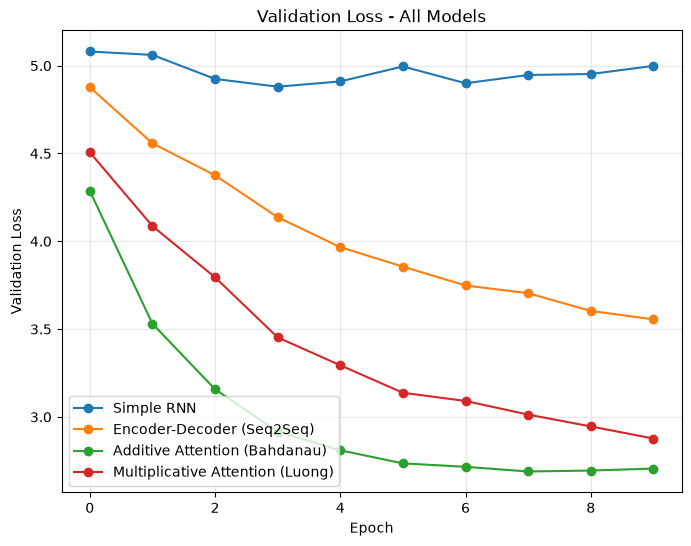

In [3]:
plt.figure(figsize=(8, 6))
for name, history in histories.items():
    plt.plot(history["val_loss"], label=name, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss - All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../results/figures/all_losses.png", dpi=150, bbox_inches="tight")
plt.show()

## Load trained checkpoints

In [4]:
def load_rnn():
    enc = EncoderRNN(len(english_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
    dec = DecoderRNN(len(spanish_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
    m = Seq2SeqRNN(enc, dec, device).to(device)
    m.load_state_dict(torch.load("../models/rnn_model.pt", map_location=device))
    return m

def load_seq2seq():
    enc = Encoder(len(english_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
    dec = Decoder(len(spanish_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
    m = Seq2Seq(enc, dec, device).to(device)
    m.load_state_dict(torch.load("../models/seq2seq_model.pt", map_location=device))
    return m

def load_bahdanau():
    attn = BahdanauAttention(config.HIDDEN_DIM)
    enc = EncoderAttentionLSTM(len(english_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
    dec = DecoderAttentionLSTM(len(spanish_vocab), config.EMB_DIM, config.HIDDEN_DIM, attn, dropout_p=config.DROPOUT)
    m = Seq2SeqAttention(enc, dec, device).to(device)
    m.load_state_dict(torch.load("../models/additive_attention_model.pt", map_location=device))
    return m

def load_luong():
    attn = LuongAttention(config.HIDDEN_DIM)
    enc = EncoderLuongLSTM(len(english_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
    dec = DecoderLuongLSTM(len(spanish_vocab), config.EMB_DIM, config.HIDDEN_DIM, attn, dropout_p=config.DROPOUT)
    m = Seq2SeqLuongAttention(enc, dec, device).to(device)
    m.load_state_dict(torch.load("../models/luong_attention_model.pt", map_location=device))
    return m

models_dict = {
    "Simple RNN": load_rnn(),
    "Encoder-Decoder (Seq2Seq)": load_seq2seq(),
    "Additive Attention (Bahdanau)": load_bahdanau(),
    "Multiplicative Attention (Luong)": load_luong(),
}
for m in models_dict.values():
    m.eval()

## Side-by-side translations

In [5]:
sentences = [
    "I am a student.",
    "She is reading a book in the library.",
    "We need to protect our environment.",
    "Can you help me solve this problem?",
]

rows = []
for s in sentences:
    row = {"english": s}
    row.update(compare_models(s, models_dict, english_vocab, spanish_vocab, device, max_len=config.MAX_DECODE_LEN))
    rows.append(row)

qual_df = pd.DataFrame(rows)
os.makedirs("../results/translations", exist_ok=True)
qual_df.to_csv("../results/translations/comparison.csv", index=False)
qual_df

,english,Simple RNN,Encoder-Decoder (Seq2Seq),Additive Attention (Bahdanau),Multiplicative Attention (Luong)
0,I am a student.,tom no que que de que <unk> .,soy un . .,soy estudiante estudiante .,soy estudiante .
1,She is reading a book in the library.,tom no que que de que <unk> .,ella es un un en un . .,ella está leyendo una libro en la biblioteca .,ella leyendo una libro en la biblioteca .
2,We need to protect our environment.,tom no que que de que <unk> .,tenemos que <unk> <unk> .,necesitamos que nuestro deber <unk> .,necesitamos <unk> nuestro <unk> .
3,Can you help me solve this problem?,¿ qué qué ?,¿ me puedo hablar este este ? ?,¿ puede ayudarme a este problema problema ?,¿ puedes ayudarme a este problema ?


## Attention: additive vs. multiplicative

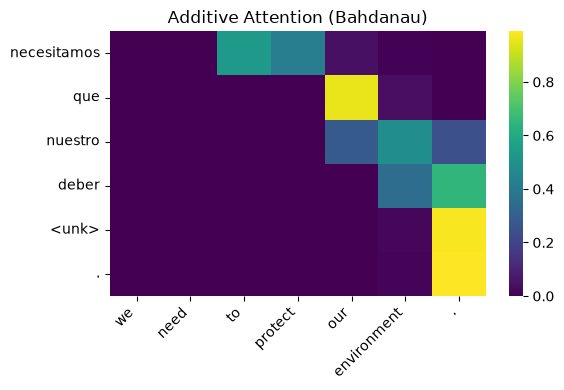

Additive Attention (Bahdanau) -> necesitamos que nuestro deber <unk> .


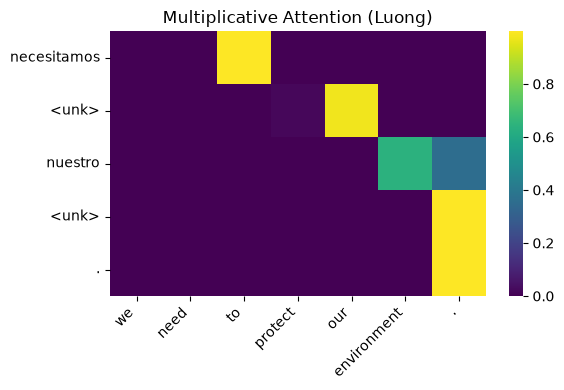

Multiplicative Attention (Luong) -> necesitamos <unk> nuestro <unk> .


In [6]:
sentence = "We need to protect our environment."
src_tokens = english_vocab.tokenize(sentence)

for name, key in [("Additive Attention (Bahdanau)", "bahdanau"), ("Multiplicative Attention (Luong)", "luong")]:
    translation, attn = translate_sentence(sentence, english_vocab, spanish_vocab, models_dict[name], device, max_len=config.MAX_DECODE_LEN)
    trg_tokens = translation.split()
    attn_arr = attn[:len(trg_tokens), :len(src_tokens)].numpy()

    plt.figure(figsize=(max(6, len(src_tokens) * 0.6), max(4, len(trg_tokens) * 0.6)))
    sns.heatmap(attn_arr, xticklabels=src_tokens, yticklabels=trg_tokens, cmap="viridis")
    plt.title(name)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"../results/figures/{key}_compare_attn.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(name, "->", translation)